# Sleep Quality Prediction: Personalized vs Generalized MLP

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
np.random.seed(42)

FEATURES = ["fatigue", "mood", "readiness", "sleep_duration_h", "soreness", "stress"]
TARGET = "sleep_quality"
N = 16

## Preprocessing Utilities


In [3]:
def train_test_split(X, y, test_size=0.2, random_state=42, subj=None):
    rng = np.random.RandomState(random_state)
    idx = rng.permutation(len(X))
    n_te = int(len(X) * test_size)
    te, tr = idx[:n_te], idx[n_te:]
    if subj is not None:
        return X[tr], X[te], y[tr], y[te], subj[tr], subj[te]
    return X[tr], X[te], y[tr], y[te]

def standard_scale(X_tr, X_te):
    mu = X_tr.mean(axis=0)
    sig = X_tr.std(axis=0) + 1e-8
    return (X_tr - mu) / sig, (X_te - mu) / sig, mu, sig

def label_encode(y):
    classes = np.unique(y)
    mapping = {c: i for i, c in enumerate(classes)}
    return np.array([mapping[v] for v in y]), classes

## Evaluation Metrics

In [4]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def macro_f1(y_true, y_pred, n_classes):
    f1s = []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1s.append(2 * p * r / (p + r) if (p + r) > 0 else 0.0)
    return float(np.mean(f1s))

def get_class_weights(y):
    classes, counts = np.unique(y, return_counts=True)
    weights = len(y) / (len(classes) * counts)
    return dict(zip(classes.tolist(), weights.tolist()))

def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def classification_report(y_true, y_pred, n_classes, classes):
    rows = []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        support = int(np.sum(y_true == c))
        rows.append({"class": classes[c], "precision": p, "recall": r,
                     "f1": f1, "support": support})
    df = pd.DataFrame(rows)
    total = df["support"].sum()
    macro    = {"class": "macro avg",
                "precision": df["precision"].mean(),
                "recall":    df["recall"].mean(),
                "f1":        df["f1"].mean(),
                "support":   total}
    weighted = {"class": "weighted avg",
                "precision": (df["precision"] * df["support"]).sum() / total,
                "recall":    (df["recall"]    * df["support"]).sum() / total,
                "f1":        (df["f1"]        * df["support"]).sum() / total,
                "support":   total}
    df = pd.concat([df, pd.DataFrame([macro, weighted])], ignore_index=True)
    df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(3)
    return df

def cohens_kappa(y_true, y_pred, n_classes):
    cm = confusion_matrix_np(y_true, y_pred, n_classes)
    n = cm.sum()
    po = np.diag(cm).sum() / n
    pe = (cm.sum(axis=0) * cm.sum(axis=1)).sum() / (n ** 2)
    return (po - pe) / (1 - pe) if (1 - pe) > 0 else 0.0

def top2_accuracy(probs, y_true):
    top2 = np.argsort(probs, axis=1)[:, -2:]
    return float(np.mean([y_true[i] in top2[i] for i in range(len(y_true))]))

def ordinal_mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true.astype(int) - y_pred.astype(int))))

## Activation Functions & Loss

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(probs, y):
    return -np.log(probs[np.arange(len(y)), y] + 1e-9).mean()

## MLP Implementation

The network architecture is: **Input(6) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(16, ReLU) → Softmax(n_classes)**

In [6]:
class MLP:
    def __init__(self, layer_sizes, lr=1e-3, dropout=0.2):
        self.lr = lr
        self.dropout = dropout
        self.weights = []
        self.biases  = []
        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / layer_sizes[i])
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * scale)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))

    def forward(self, X, training=False):
        self.cache = []
        out = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = out @ W + b
            if i < len(self.weights) - 1:
                a = relu(z)
                mask = None
                if training and self.dropout > 0:
                    mask = (np.random.rand(*a.shape) > self.dropout) / (1 - self.dropout)
                    a = a * mask
                self.cache.append((out, z, mask))
                out = a
            else:          
                a = softmax(z)
                self.cache.append((out, z, None))
                out = a
        return out

    def backward(self, y, class_weights=None):
        n = len(y)
        z_out = self.cache[-1][1]
        delta = softmax(z_out)
        delta[np.arange(n), y] -= 1
        delta /= n
        if class_weights is not None:
            sw = np.array([class_weights.get(int(yi), 1.0) for yi in y])
            delta *= sw[:, None]
        grads_W = [None] * len(self.weights)
        grads_b = [None] * len(self.weights)
        for i in reversed(range(len(self.weights))):
            x_in, z, mask = self.cache[i]
            grads_W[i] = x_in.T @ delta
            grads_b[i] = delta.sum(axis=0, keepdims=True)
            if i > 0:
                delta = delta @ self.weights[i].T
                _, z_prev, mask_prev = self.cache[i - 1]
                delta = delta * relu_grad(z_prev)
                if mask_prev is not None:
                    delta *= mask_prev
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * grads_W[i]
            self.biases[i]  -= self.lr * grads_b[i]

    def fit(self, X_tr, y_tr, X_val, y_val,
            epochs=300, batch_size=16, patience=25, class_weights=None):
        best_loss = np.inf
        best_W    = [w.copy() for w in self.weights]
        best_b    = [b.copy() for b in self.biases]
        wait      = 0
        for _ in range(epochs):
            idx = np.random.permutation(len(X_tr))
            for start in range(0, len(X_tr), batch_size):
                batch = idx[start:start + batch_size]
                self.forward(X_tr[batch], training=True)
                self.backward(y_tr[batch], class_weights)
            val_loss = cross_entropy(self.forward(X_val), y_val)
            if val_loss < best_loss - 1e-5:
                best_loss = val_loss
                best_W    = [w.copy() for w in self.weights]
                best_b    = [b.copy() for b in self.biases]
                wait      = 0
            else:
                wait += 1
                if wait >= patience:
                    break
        self.weights, self.biases = best_W, best_b

    def predict(self, X):
        return self.forward(X, training=False)

## Training Helper & Data Loader

In [7]:
def train_eval(X_tr, y_tr, X_te, y_te, n_classes):
    X_tr_s, X_te_s, mu, sig = standard_scale(X_tr, X_te)
    cw    = get_class_weights(y_tr)
    model = MLP([len(FEATURES), 64, 32, 16, n_classes], lr=1e-3, dropout=0.2)
    model.fit(X_tr_s, y_tr, X_te_s, y_te,
              epochs=300, batch_size=16, patience=25, class_weights=cw)
    probs  = model.predict(X_te_s)
    y_pred = probs.argmax(axis=1)
    acc    = accuracy(y_te, y_pred)
    f1     = macro_f1(y_te, y_pred, n_classes)
    return acc, f1, model, mu, sig, y_pred, probs

def load_subject(i):
    df = pd.read_csv(f"wellness_{i}.csv")
    df = df[df[TARGET] != 0]
    X  = df[FEATURES].values.astype(float)
    y, classes = label_encode(df[TARGET].values)
    return X, y, classes, df

## Personalized Models


In [8]:
print("Personalized results:")
pers_results = []
pers_cms     = []
all_X        = []
all_y_raw    = []
all_subj     = []

for i in range(1, N + 1):
    X, y, classes, df = load_subject(i)
    n_classes = len(classes)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    if len(X_te) < 5:
        pers_results.append({"subject": i, "acc": np.nan, "f1": np.nan})
        pers_cms.append(None)
    else:
        acc, f1, model, mu, sig, y_pred, probs = train_eval(X_tr, y_tr, X_te, y_te, n_classes)
        print(f"Subject {i:2d}: acc={acc:.3f}  macro-f1={f1:.3f}  "
              f"(n={len(X)}, classes={list(classes)})")
        pers_results.append({"subject": i, "acc": acc, "f1": f1})
        pers_cms.append((confusion_matrix_np(y_te, y_pred, n_classes), classes, y_te, y_pred, probs))

    all_X.append(df[FEATURES].values.astype(float))
    all_y_raw.append(df[TARGET].values)
    all_subj.extend([i] * len(df))

pers_df = pd.DataFrame(pers_results)

Personalized results:
Subject  1: acc=0.296  macro-f1=0.121  (n=138, classes=[1, 2, 3, 4])
Subject  2: acc=0.789  macro-f1=0.294  (n=99, classes=[2, 3, 4])
Subject  3: acc=0.938  macro-f1=0.654  (n=82, classes=[2, 3, 4])
Subject  4: acc=0.241  macro-f1=0.199  (n=145, classes=[1, 2, 3, 4, 5])
Subject  5: acc=0.407  macro-f1=0.157  (n=135, classes=[1, 2, 3, 4])
Subject  6: acc=0.552  macro-f1=0.433  (n=147, classes=[2, 3, 4])
Subject  7: acc=0.423  macro-f1=0.412  (n=133, classes=[2, 3, 4, 5])
Subject  8: acc=0.400  macro-f1=0.286  (n=104, classes=[2, 3, 4, 5])
Subject  9: acc=0.500  macro-f1=0.475  (n=102, classes=[2, 3, 4, 5])
Subject 10: acc=0.316  macro-f1=0.322  (n=96, classes=[1, 2, 3, 4])
Subject 11: acc=0.762  macro-f1=0.419  (n=107, classes=[2, 3, 4])
Subject 12: acc=0.438  macro-f1=0.271  (n=83, classes=[1, 2, 3, 4])
Subject 13: acc=0.214  macro-f1=0.145  (n=72, classes=[1, 2, 3, 4])
Subject 14: acc=0.480  macro-f1=0.368  (n=125, classes=[2, 3, 4, 5])
Subject 15: acc=0.211  mac

## Generalized Model

In [9]:
print("Generalized results:")

all_X     = np.vstack(all_X)
all_y_raw = np.concatenate(all_y_raw)
all_subj  = np.array(all_subj)

all_y, global_classes = label_encode(all_y_raw)
n_classes_global = len(global_classes)

X_tr_g, X_te_g, y_tr_g, y_te_g, subj_tr, subj_te = train_test_split(
    all_X, all_y, test_size=0.2, random_state=42, subj=all_subj
)

acc_g, f1_g, gen_model, mu_g, sig_g, y_pred_g, probs_g = train_eval(
    X_tr_g, y_tr_g, X_te_g, y_te_g, n_classes_global
)
print(f"Generalized: acc={acc_g:.3f}  macro-f1={f1_g:.3f}\n")

gen_per_subj = []
print("Per-subject accuracy of generalized model:")
for i in range(1, N + 1):
    mask = subj_te == i
    if mask.sum() < 2:
        gen_per_subj.append({"subject": i, "acc": np.nan, "f1": np.nan})
        continue
    a = accuracy(y_te_g[mask], y_pred_g[mask])
    f = macro_f1(y_te_g[mask], y_pred_g[mask], n_classes_global)
    gen_per_subj.append({"subject": i, "acc": a, "f1": f})
    print(f"Subject {i:2d}: acc={a:.3f} macro-f1={f:.3f}")

gen_subj_df = pd.DataFrame(gen_per_subj)

Generalized results:
Generalized: acc=0.470  macro-f1=0.316

Per-subject accuracy of generalized model:
Subject  1: acc=0.583 macro-f1=0.242
Subject  2: acc=0.867 macro-f1=0.186
Subject  3: acc=0.900 macro-f1=0.322
Subject  4: acc=0.343 macro-f1=0.228
Subject  5: acc=0.394 macro-f1=0.223
Subject  6: acc=0.400 macro-f1=0.229
Subject  7: acc=0.560 macro-f1=0.362
Subject  8: acc=0.429 macro-f1=0.222
Subject  9: acc=0.312 macro-f1=0.211
Subject 10: acc=0.522 macro-f1=0.342
Subject 11: acc=0.462 macro-f1=0.133
Subject 12: acc=0.550 macro-f1=0.320
Subject 13: acc=0.375 macro-f1=0.233
Subject 14: acc=0.333 macro-f1=0.151
Subject 15: acc=0.375 macro-f1=0.200
Subject 16: acc=0.250 macro-f1=0.187


## 9. Summary Table

In [17]:
summary_df = pd.DataFrame({
    "Model": ["Personalized (mean ± std)", "Generalized (global)", "Generalized (per-subj mean)"],
    "Accuracy": [
        f"{pers_df['acc'].mean():.3f} ± {pers_df['acc'].std():.3f}",
        f"{acc_g:.3f}",
        f"{gen_subj_df['acc'].mean():.3f} ± {gen_subj_df['acc'].std():.3f}"
    ],
    "Macro-F1": [
        f"{pers_df['f1'].mean():.3f} ± {pers_df['f1'].std():.3f}",
        f"{f1_g:.3f}",
        f"{gen_subj_df['f1'].mean():.3f} ± {gen_subj_df['f1'].std():.3f}"
    ]
})
display(summary_df.style.hide(axis="index"))

n_samples = [pd.read_csv(f"wellness_{i}.csv").shape[0] for i in range(1, N+1)]
results_table = pd.DataFrame({
    "Subject":   range(1, N + 1),
    "N_samples": n_samples,
    "Pers_Acc":  pers_df["acc"].round(3).values,
    "Gen_Acc":   gen_subj_df["acc"].round(3).values,
    "Pers_F1":   pers_df["f1"].round(3).values,
    "Gen_F1":    gen_subj_df["f1"].round(3).values,
    "Delta_Acc": (pers_df["acc"] - gen_subj_df["acc"]).round(3).values,
    "Pers_Wins": (pers_df["acc"] > gen_subj_df["acc"]).values,
})
print("\n")
display(results_table.style.hide(axis="index"))
print(f"\nPersonalized wins: {results_table['Pers_Wins'].sum()}/16 subjects")

Model,Accuracy,Macro-F1
Personalized (mean ± std),0.459 ± 0.212,0.321 ± 0.143
Generalized (global),0.470,0.316
Generalized (per-subj mean),0.478 ± 0.184,0.237 ± 0.067


Subject,N_samples,Pers_Acc,Gen_Acc,Pers_F1,Gen_F1,Delta_Acc,Pers_Wins
1,138,0.296000,0.583000,0.121000,0.242000,-0.287000,False
2,99,0.789000,0.867000,0.294000,0.186000,-0.077000,False
3,82,0.938000,0.900000,0.654000,0.322000,0.037000,True
4,145,0.241000,0.343000,0.199000,0.228000,-0.101000,False
5,137,0.407000,0.394000,0.157000,0.223000,0.013000,True
6,147,0.552000,0.400000,0.433000,0.229000,0.152000,True
7,133,0.423000,0.560000,0.412000,0.362000,-0.137000,False
8,104,0.400000,0.429000,0.286000,0.222000,-0.029000,False
9,102,0.500000,0.312000,0.475000,0.211000,0.188000,True
10,96,0.316000,0.522000,0.322000,0.342000,-0.206000,False



Personalized wins: 7/16 subjects


## Bar Chart Comparison

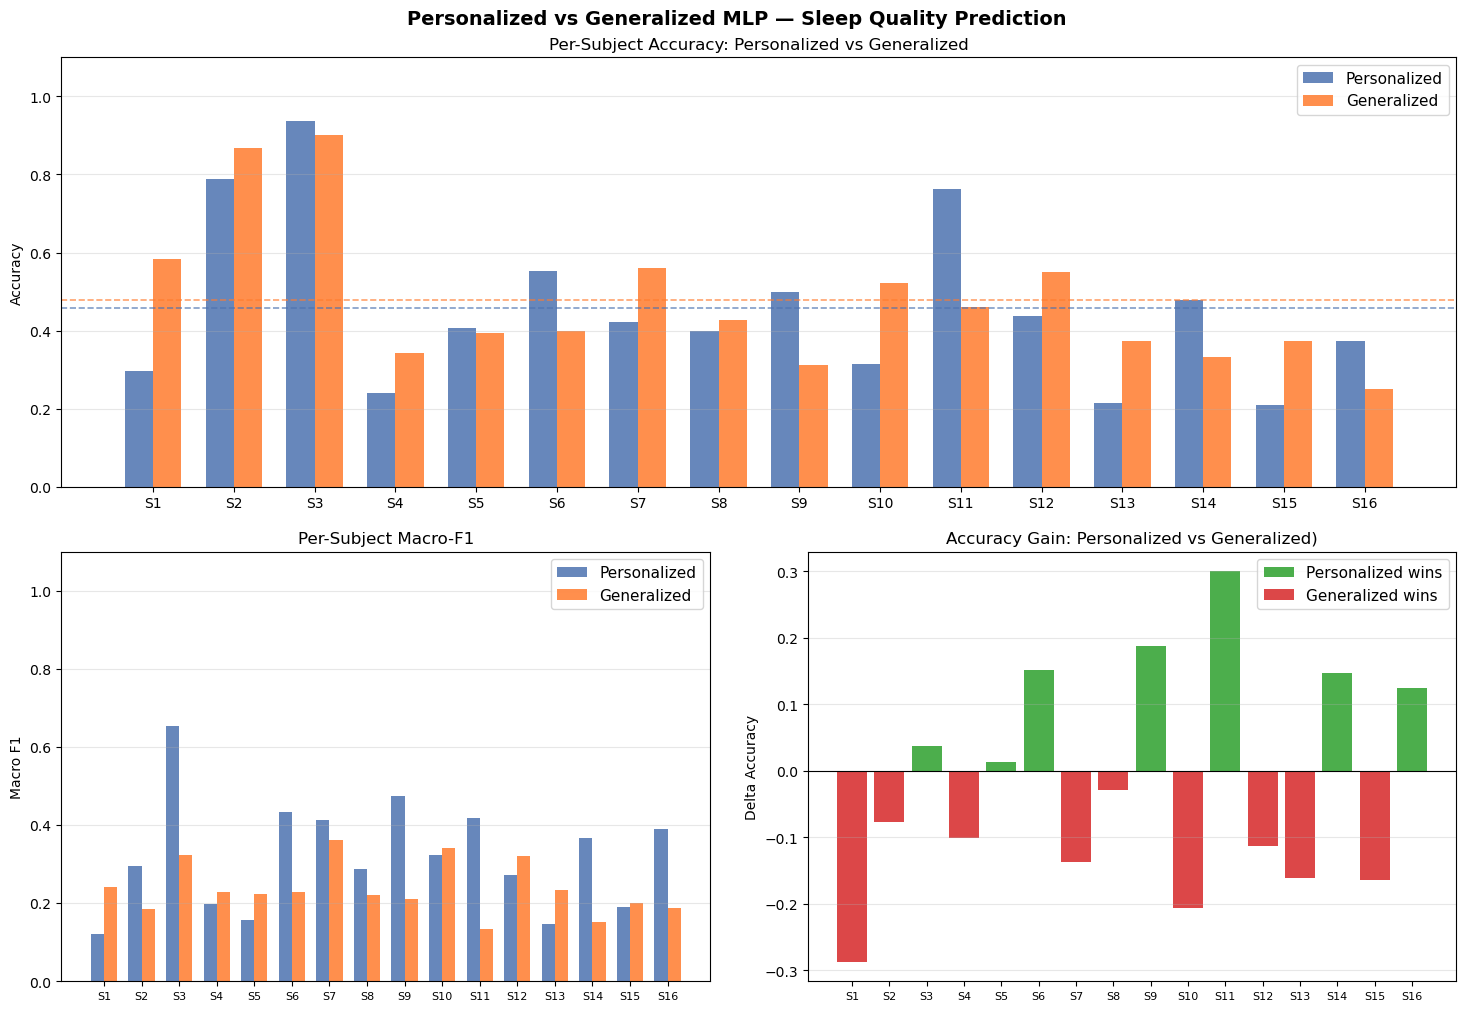

In [11]:
subj_labels = [f"S{i}" for i in range(1, N + 1)]
x = np.arange(N)
w = 0.35

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, :])
ax1.bar(x - w/2, pers_df["acc"],     w, label="Personalized", color="#4C72B0", alpha=0.85)
ax1.bar(x + w/2, gen_subj_df["acc"], w, label="Generalized",  color="#ff7b2e", alpha=0.85)
ax1.axhline(pers_df["acc"].mean(),     color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.7)
ax1.axhline(gen_subj_df["acc"].mean(), color="#ff7b2e", linestyle="--", linewidth=1.2, alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(subj_labels)
ax1.set_ylabel("Accuracy")
ax1.set_title("Per-Subject Accuracy: Personalized vs Generalized")
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=11)
ax1.grid(axis="y", alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(x - w/2, pers_df["f1"],     w, label="Personalized", color="#4C72B0", alpha=0.85)
ax2.bar(x + w/2, gen_subj_df["f1"], w, label="Generalized",  color="#ff7b2e", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(subj_labels, fontsize=8)
ax2.set_ylabel("Macro F1")
ax2.set_title("Per-Subject Macro-F1")
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
delta_acc = (pers_df["acc"] - gen_subj_df["acc"]).values
colors = ["#2ca02c" if d > 0 else "#d62728" for d in delta_acc]
ax3.bar(x, delta_acc, color=colors, alpha=0.85)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(subj_labels, fontsize=8)
ax3.set_ylabel("Delta Accuracy")
ax3.set_title("Accuracy Gain: Personalized vs Generalized)")
ax3.grid(axis="y", alpha=0.3)

legend_elements = [Patch(facecolor="#2ca02c", alpha=0.85, label="Personalized wins"),
                   Patch(facecolor="#d62728", alpha=0.85, label="Generalized wins")]
ax3.legend(handles=legend_elements, loc="upper right", fontsize=11)

plt.suptitle("Personalized vs Generalized MLP — Sleep Quality Prediction",
             fontsize=14, fontweight="bold", y=0.92)
plt.show()

## Confusion Matrices

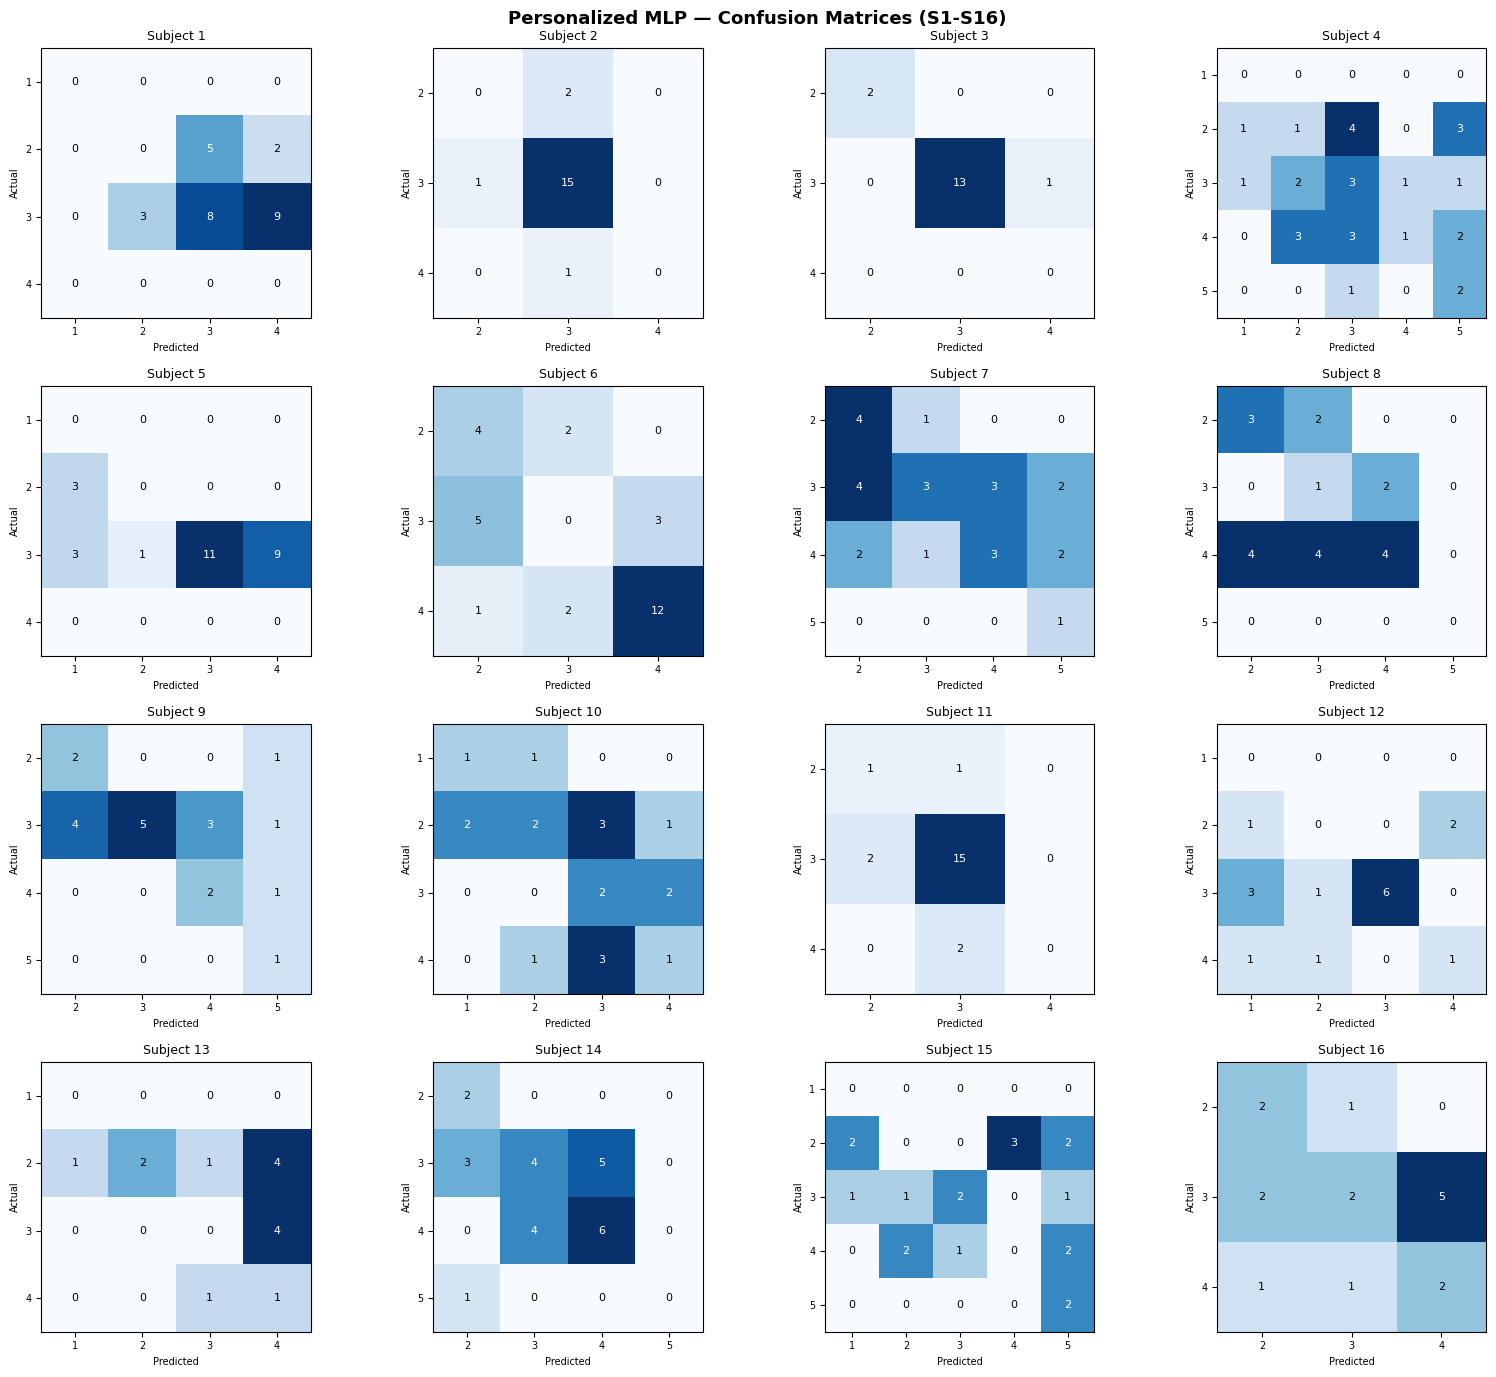

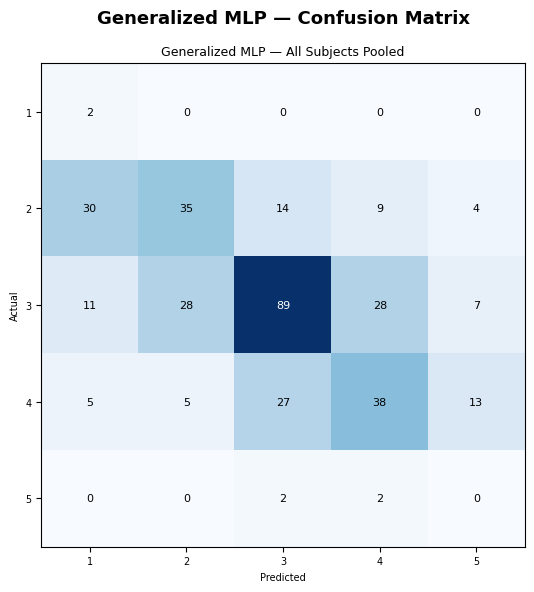

In [12]:
def plot_cm(ax, cm, title, classes):
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=9)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_xticklabels(classes, fontsize=7)
    ax.set_yticks(ticks); ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel("Predicted", fontsize=7)
    ax.set_ylabel("Actual", fontsize=7)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > thresh else "black")

# personalized
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle("Personalized MLP — Confusion Matrices (S1-S16)", fontsize=13, fontweight="bold")
for idx, ax in enumerate(axes.flat):
    if pers_cms[idx] is None:
        ax.axis("off"); ax.set_title(f"S{idx+1} (skipped)", fontsize=9); continue
    cm, classes, *_ = pers_cms[idx]
    plot_cm(ax, cm, f"Subject {idx+1}", classes)
plt.tight_layout()
plt.show()

# generalized
cm_g = confusion_matrix_np(y_te_g, y_pred_g, n_classes_global)
fig2, ax2 = plt.subplots(figsize=(7, 6))
plot_cm(ax2, cm_g, "Generalized MLP — All Subjects Pooled", global_classes)
fig2.suptitle("Generalized MLP — Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [26]:
# Personalized reports
for idx in range(N):
    if pers_cms[idx] is None:
        continue
    cm, classes, y_te, y_pred, probs = pers_cms[idx]
    kappa = cohens_kappa(y_te, y_pred, len(classes))
    top2  = top2_accuracy(probs, y_te)
    mae   = ordinal_mae(y_te, y_pred)
    display(classification_report(y_te, y_pred, len(classes), classes))

# Generalized report
kappa_g  = cohens_kappa(y_te_g, y_pred_g, n_classes_global)
top2_g   = top2_accuracy(probs_g, y_te_g)
mae_g    = ordinal_mae(y_te_g, y_pred_g)
display(classification_report(y_te_g, y_pred_g, n_classes_global, global_classes))

# Aggregate single metrics across all subjects
rows = []
for idx in range(N):
    if pers_cms[idx] is None:
        continue
    cm, classes, y_te, y_pred, probs = pers_cms[idx]
    n_classes = len(classes)
    kappa = cohens_kappa(y_te, y_pred, n_classes)
    top2  = top2_accuracy(probs, y_te)
    mae = ordinal_mae(y_te, y_pred)
    acc = accuracy(y_te, y_pred)
    report = classification_report(y_te, y_pred, n_classes, classes)
    macro = report[report["class"] == "macro avg"].iloc[0]
    rows.append({
        "Subject":f"S{idx+1}",
        "Accuracy":round(acc, 3),
        "Precision":round(macro["precision"], 3),
        "Recall":round(macro["recall"], 3),
        "F1":round(macro["f1"], 3),
        "Kappa":round(kappa, 3),
        "Top2-Acc":round(top2, 3),
        "MAE":round(mae, 3),
    })

# Add generalized row
gen_report = classification_report(y_te_g, y_pred_g, n_classes_global, global_classes)
gen_macro  = gen_report[gen_report["class"] == "macro avg"].iloc[0]
rows.append({
    "Subject":"Generalized",
    "Accuracy":round(accuracy(y_te_g, y_pred_g), 3),
    "Precision":round(gen_macro["precision"], 3),
    "Recall":round(gen_macro["recall"], 3),
    "F1":round(gen_macro["f1"], 3),
    "Kappa":round(kappa_g, 3),
    "Top2-Acc":round(top2_g, 3),
    "MAE": round(mae_g, 3),
})

agg_df = pd.DataFrame(rows)
print("\nAll Subjects vs Generalized")
display(agg_df)

,class,precision,recall,f1,support
0,1,0.000,0.000,0.000,0
1,2,0.000,0.000,0.000,7
2,3,0.615,0.400,0.485,20
3,4,0.000,0.000,0.000,0
4,macro avg,0.154,0.100,0.121,27
5,weighted avg,0.456,0.296,0.359,27


,class,precision,recall,f1,support
0,2,0.000,0.000,0.000,2
1,3,0.833,0.938,0.882,16
2,4,0.000,0.000,0.000,1
3,macro avg,0.278,0.312,0.294,19
4,weighted avg,0.702,0.789,0.743,19


,class,precision,recall,f1,support
0,2,1.000,1.000,1.000,2
1,3,1.000,0.929,0.963,14
2,4,0.000,0.000,0.000,0
3,macro avg,0.667,0.643,0.654,16
4,weighted avg,1.000,0.938,0.968,16


,class,precision,recall,f1,support
0,1,0.000,0.000,0.000,0
1,2,0.167,0.111,0.133,9
2,3,0.273,0.375,0.316,8
3,4,0.500,0.111,0.182,9
4,5,0.250,0.667,0.364,3
5,macro avg,0.238,0.253,0.199,29
6,weighted avg,0.308,0.241,0.223,29


,class,precision,recall,f1,support
0,1,0.000,0.000,0.000,0
1,2,0.000,0.000,0.000,3
2,3,1.000,0.458,0.629,24
3,4,0.000,0.000,0.000,0
4,macro avg,0.250,0.115,0.157,27
5,weighted avg,0.889,0.407,0.559,27


...

,class,precision,recall,f1,support
0,1,0.000,0.000,0.000,0
1,2,0.000,0.000,0.000,7
2,3,0.667,0.400,0.500,5
3,4,0.000,0.000,0.000,5
4,5,0.286,1.000,0.444,2
5,macro avg,0.190,0.280,0.189,19
6,weighted avg,0.206,0.211,0.178,19


,class,precision,recall,f1,support
0,2,0.400,0.667,0.500,3
1,3,0.500,0.222,0.308,9
2,4,0.286,0.500,0.364,4
3,macro avg,0.395,0.463,0.390,16
4,weighted avg,0.428,0.375,0.358,16


,class,precision,recall,f1,support
0,1,0.042,1.000,0.080,2
1,2,0.515,0.380,0.438,92
2,3,0.674,0.546,0.603,163
3,4,0.494,0.432,0.461,88
4,5,0.000,0.000,0.000,4
5,macro avg,0.345,0.472,0.316,349
6,weighted avg,0.575,0.470,0.514,349



All Subjects vs Generalized


,Subject,Accuracy,Precision,Recall,F1,Kappa,Top2-Acc,MAE
0,S1,0.296,0.154,0.100,0.121,-0.145,0.593,0.778
1,S2,0.789,0.278,0.312,0.294,-0.070,0.947,0.211
2,S3,0.938,0.667,0.643,0.654,0.771,1.000,0.062
3,S4,0.241,0.238,0.253,0.199,0.029,0.483,1.172
4,S5,0.407,0.250,0.115,0.157,0.065,0.778,0.704
5,S6,0.552,0.400,0.489,0.433,0.281,0.931,0.483
6,S7,0.423,0.425,0.606,0.412,0.240,0.731,0.731
7,S8,0.400,0.310,0.317,0.286,0.118,0.650,0.800
8,S9,0.500,0.496,0.679,0.475,0.329,0.750,0.650
9,S10,0.316,0.333,0.362,0.322,0.089,0.526,0.789


In [15]:
# Aggregate metrics across all personalized subjects
pers_precisions, pers_recalls, pers_f1s, pers_kappas, pers_top2s, pers_maes, pers_accs = [], [], [], [], [], [], []

for idx in range(N):
    if pers_cms[idx] is None:
        continue
    cm, classes, y_te, y_pred, probs = pers_cms[idx]
    n_classes = len(classes)

    report = classification_report(y_te, y_pred, n_classes, classes)
    macro_row = report[report["class"] == "macro avg"].iloc[0]
    pers_precisions.append(macro_row["precision"])
    pers_recalls.append(macro_row["recall"])
    pers_f1s.append(macro_row["f1"])
    pers_accs.append(accuracy(y_te, y_pred))
    pers_kappas.append(cohens_kappa(y_te, y_pred, n_classes))
    pers_top2s.append(top2_accuracy(probs, y_te))
    pers_maes.append(ordinal_mae(y_te, y_pred))

# Generalized metrics
gen_report = classification_report(y_te_g, y_pred_g, n_classes_global, global_classes)
gen_macro = gen_report[gen_report["class"] == "macro avg"].iloc[0]
gen_precision = gen_macro["precision"]
gen_recall = gen_macro["recall"]
gen_f1 = gen_macro["f1"]
gen_acc = accuracy(y_te_g, y_pred_g)
gen_kappa = cohens_kappa(y_te_g, y_pred_g, n_classes_global)
gen_top2 = top2_accuracy(probs_g, y_te_g)
gen_mae = ordinal_mae(y_te_g, y_pred_g)

# Summary comparison table
metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Cohen Kappa", "Top-2 Accuracy", "MAE"]
pers_means = [np.mean(pers_accs), np.mean(pers_precisions), np.mean(pers_recalls),
              np.mean(pers_f1s), np.mean(pers_kappas), np.mean(pers_top2s), np.mean(pers_maes)]
pers_stds = [np.std(pers_accs), np.std(pers_precisions), np.std(pers_recalls),
              np.std(pers_f1s), np.std(pers_kappas), np.std(pers_top2s), np.std(pers_maes)]
gen_vals = [gen_acc, gen_precision, gen_recall, gen_f1, gen_kappa, gen_top2, gen_mae]

summary = pd.DataFrame({
    "Metric":        metrics,
    "Personalized":  [f"{m:.3f} ± {s:.3f}" for m, s in zip(pers_means, pers_stds)],
    "Generalized":   [f"{v:.3f}" for v in gen_vals],
    "Pers_Better":   ["Yes" if (m > v if met != "MAE" else m < v) else "No"
                      for m, v, met in zip(pers_means, gen_vals, metrics)]
})
summary

,Metric,Personalized,Generalized,Pers_Better
0,Accuracy,0.459 ± 0.205,0.470,No
1,Macro Precision,0.343 ± 0.120,0.345,No
2,Macro Recall,0.374 ± 0.174,0.472,No
3,Macro F1,0.321 ± 0.138,0.316,Yes
4,Cohen Kappa,0.152 ± 0.202,0.258,No
5,Top-2 Accuracy,0.744 ± 0.153,0.791,No
6,MAE,0.713 ± 0.343,0.679,No
